In [95]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
from iminuit import Minuit
from iminuit import cost

colors = [
    '#D31F11'    ,  # red
    '#F47A00'    ,  # orange
    '#62C8D3'    ,  # light blue
    '#007191'    ,  # dark blue
    '#7A3E9D'    ,  # purple
    '#55A630'    ,  # green
    '#A3C72E'    ,  # lime
    '#595959'       # gray
]
plt.rcParams['font.family'] = 'monospace'

### Data: w/o ambient light

In [96]:
stage_0 = pd.read_csv('time_domain_data/without_ambient/stage_0.csv', delimiter=',', header = 1, names =['Time', 'ChA'])
stage_3 = pd.read_csv('time_domain_data/without_ambient/stage_3_04.csv', delimiter=',', header = 1, names =['Time', 'ChA', 'ChB'])
stage_4 = pd.read_csv('time_domain_data/without_ambient/stage_4_02.csv', delimiter=',', header = 1, names =['Time', 'ChA', 'ChB'])
stage_5 = pd.read_csv('time_domain_data/without_ambient/stage_5_02.csv', delimiter=',', header = 1, names =['Time', 'ChA', 'ChB'])

In [97]:
#Convert time from stage0 from ms to mikroseconds, and mV to V: 
time0 = stage_0['Time'] * 1e3
cha0 = stage_0['ChA'] #in mV
#And import the other stages:
time3 = stage_3['Time'] 
cha3 = stage_3['ChA']
chb3 = stage_3['ChB']

time4 = stage_4['Time']
cha4 = stage_4['ChA']
chb4 = stage_4['ChB']

time5 = stage_5['Time']
cha5 = stage_5['ChA']
chb5 = stage_5['ChB']

### Errors

Stage 5: ChA mean = 0.84 V, ChA std = 0.02 V


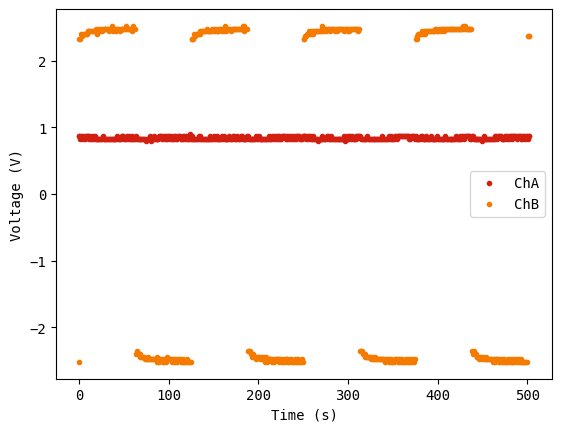

In [98]:
plt.plot(time5, cha5, '.', color=colors[0], label='ChA')
plt.plot(time5, chb5, '.', color=colors[1], label='ChB')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.legend()
print(f"Stage 5: ChA mean = {np.mean(cha5):.2f} V, ChA std = {np.std(cha5):.2f} V")

In [99]:
def constant(x, c):
    return np.ones_like(x) * c


clin = cost.LeastSquares(time5, cha5 , np.ones_like(cha5)*0.005, constant)
mlin = Minuit(clin, c = 1)
mlin.migrad()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 7625 (χ²/ndof = 15.2)      │              Nfcn = 15               │
│ EDM = 6.44e-13 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ c    │ 839.66e-3 │  0.22e-3  │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬──────────┐
│   │        c │
├───┼──────────┤
│ c │ 4.96e-08 │
└───┴──────────┘

Linear Fit Residuals: std = 0.02 V


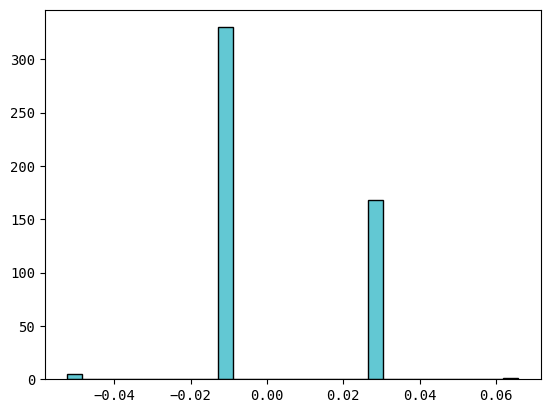

In [100]:
lin_resids = cha5 - constant(time5, *mlin.values)
print(f"Linear Fit Residuals: std = {np.std(lin_resids):.2f} V")
plt.hist(lin_resids, bins=30, color=colors[2], edgecolor='k');

In [101]:
def sine(x, A, w, phi, c):
    return A * np.sin(w * x + phi) + c

# Estimate frequency from FFT
fft_vals = np.fft.rfft(cha3)
fft_freqs = np.fft.rfftfreq(len(cha3), d=(time3[1] - time3[0]))
dominant_idx = np.argmax(np.abs(fft_vals[1:])) + 1  # +1 to correct index
f_guess = fft_freqs[dominant_idx] * 2 * np.pi
print(f_guess)


csine = cost.LeastSquares(time3, cha3 , np.ones_like(cha3)*0.1, sine)
msine = Minuit(csine, A = 1, w = f_guess, phi = 0, c = 0)
msine.migrad()

0.04986655005698084


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 110.4 (χ²/ndof = 0.2)      │              Nfcn = 109              │
│ EDM = 3.41e-07 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ A    │   0.822   │   0.006   │            │            │         │         │       │
│ 1 │ w    │ 50.38e-3  │  0.05e-3  │            │            │         │         │       │
│ 2 │ phi  │  -0.942   │   0.015   │            │            │         │         │       │
│ 3 │ c    │   0.051   │   0.005   │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌─────┬─────────────────────────────────────────┐
│     │         A         w       phi         c │
├─────┼─────────────────────────────────────────┤
│   A │  3.96e-05   -2.7e-9         0         0 │
│   w │   -2.7e-9  2.92e-09 -699.3e-9   35.3e-9 │
│ phi │         0 -699.3e-9  0.000227 -0.009e-3 │
│   c │         0   35.3e-9 -0.009e-3  2.03e-05 │
└─────┴─────────────────────────────────────────┘

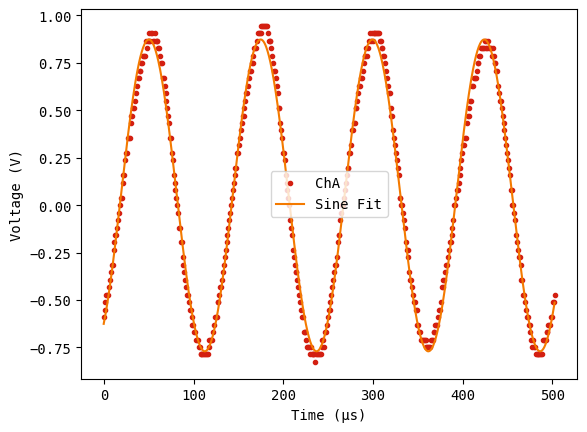

In [102]:
plt.plot(time3, cha3, '.', color=colors[0], label='ChA')
xx = np.linspace(time3.min(), time3.max(), 1000)
plt.plot(xx, sine(xx, *msine.values), '-', color=colors[1], label='Sine Fit')
plt.xlabel('Time (µs)')
plt.ylabel('Voltage (V)')
plt.legend();

Sine Fit Residuals: std = 0.05 V


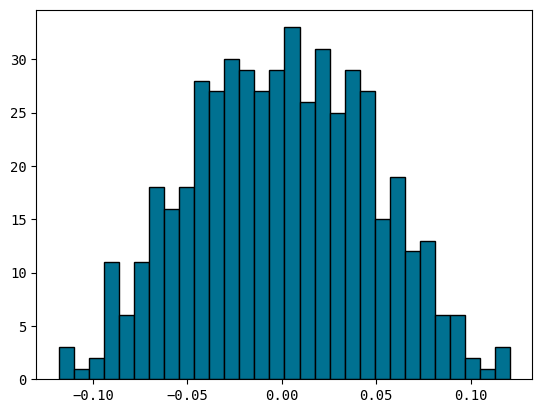

In [103]:
sinresids = cha3 - sine(time3, *msine.values)
print(f"Sine Fit Residuals: std = {np.std(sinresids):.2f} V")
plt.hist(sinresids, bins=30, color=colors[3], edgecolor='k');

### Plot the data:

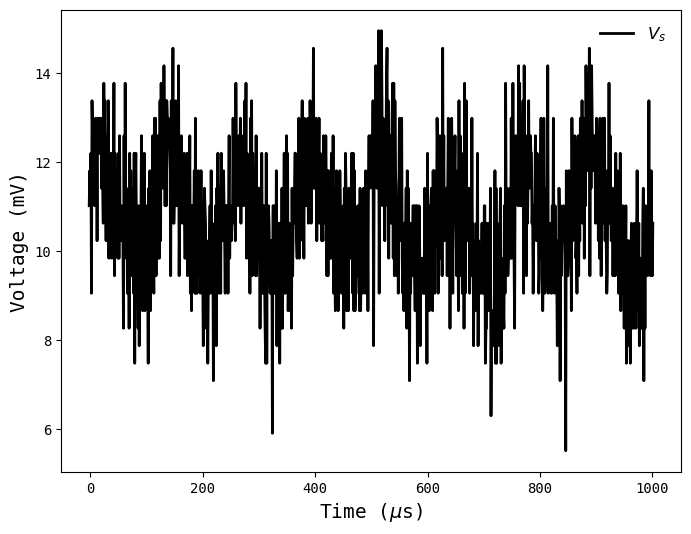

In [104]:
fig, ax = plt.subplots(figsize=(8,6))

ax.plot(time0, cha0, '-', linewidth =2, color='k', label = f'$V_s$')
ax.set_xlabel(f'Time ($\\mu$s)', fontsize=14)
ax.set_ylabel('Voltage (mV)', fontsize=14)

ax.legend(loc = 'best', fontsize = 12, frameon = False);

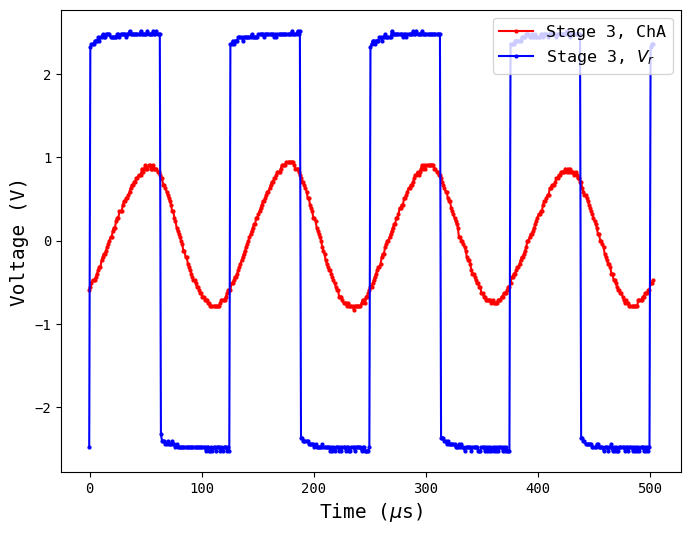

In [105]:
fig, ax = plt.subplots(figsize=(8,6))
ax.plot(time3, cha3, 'o-', ms = 2, color='r', label = 'Stage 3, ChA')
ax.plot(time3, chb3, 'o-', ms = 2, color='b', label = f'Stage 3, $V_r$')
ax.set_xlabel(f'Time ($\\mu$s)', fontsize=14)
ax.set_ylabel('Voltage (V)', fontsize=14)
ax.legend(loc = 'upper right', fontsize = 12);

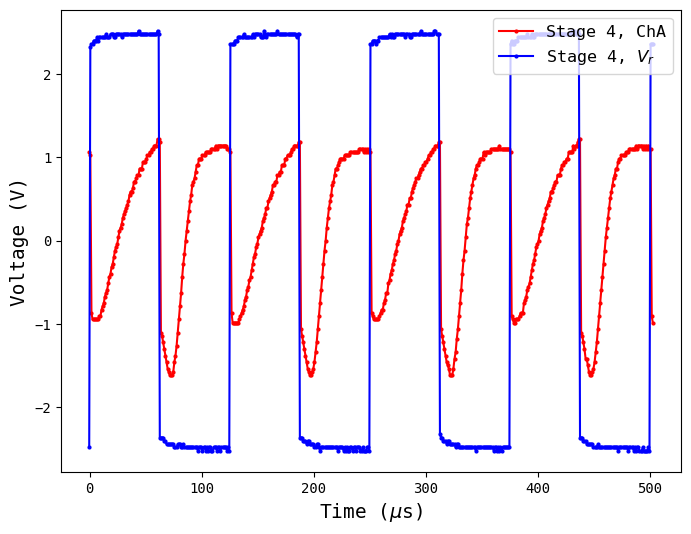

In [106]:
fig, ax = plt.subplots(figsize=(8,6))
ax.plot(time4, cha4, 'o-', ms = 2, color='r', label = 'Stage 4, ChA')
ax.plot(time4, chb4, 'o-', ms = 2, color='b', label = f'Stage 4, $V_r$')
ax.set_xlabel(f'Time ($\\mu$s)', fontsize=14)
ax.set_ylabel('Voltage (V)', fontsize=14)
ax.legend(loc = 'upper right', fontsize = 12);

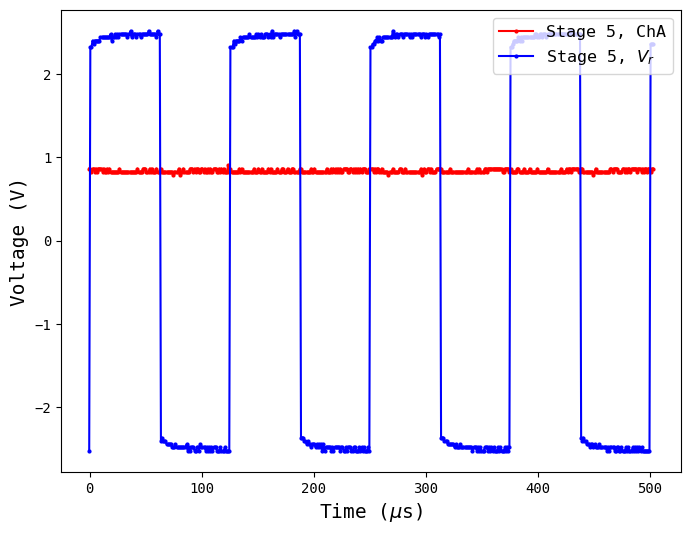

In [107]:
fig, ax = plt.subplots(figsize=(8,6))
ax.plot(time5, cha5, 'o-', ms = 2, color='r', label = 'Stage 5, ChA')
ax.plot(time5, chb5, 'o-', ms = 2, color='b', label = f'Stage 5, $V_r$')
ax.set_xlabel(f'Time ($\\mu$s)', fontsize=14)
ax.set_ylabel('Voltage (V)', fontsize=14)
ax.legend(loc = 'upper right', fontsize = 12);

### Plot the data together, such that we can see the effect of each stage. 

### Stage 0 + V_ref

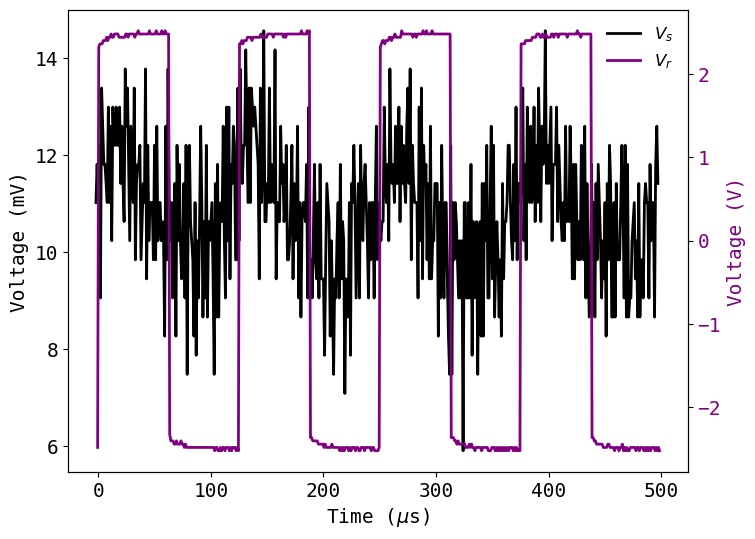

In [108]:
fig, ax = plt.subplots(figsize=(8,6))

line_ori = ax.plot(time0[:500], cha0[:500], '-', linewidth =2, color='k', label = f'$V_s$')
ax.set_xlabel(f'Time ($\\mu$s)', fontsize=14)
ax.set_ylabel('Voltage (mV)', fontsize=14, color = 'k')
ax.tick_params(axis='y', labelcolor='k')
ax.tick_params(axis='both', which='major', labelsize=14)

ax_twin = ax.twinx()
line_twin = ax_twin.plot(time3[:500], chb3[:500], '-', linewidth =2, color='purple', label = f'$V_r$')
ax_twin.set_ylabel('Voltage (V)', fontsize=14, color = 'purple')
ax_twin.tick_params(axis='y', labelcolor='purple')
ax_twin.tick_params(axis='both', which='major', labelsize=14)

lines = [line_ori[0], line_twin[0]]
labels = [line.get_label() for line in lines]
ax.legend(lines, labels, loc='best', fontsize =12, frameon=False);

### Stage 3->4

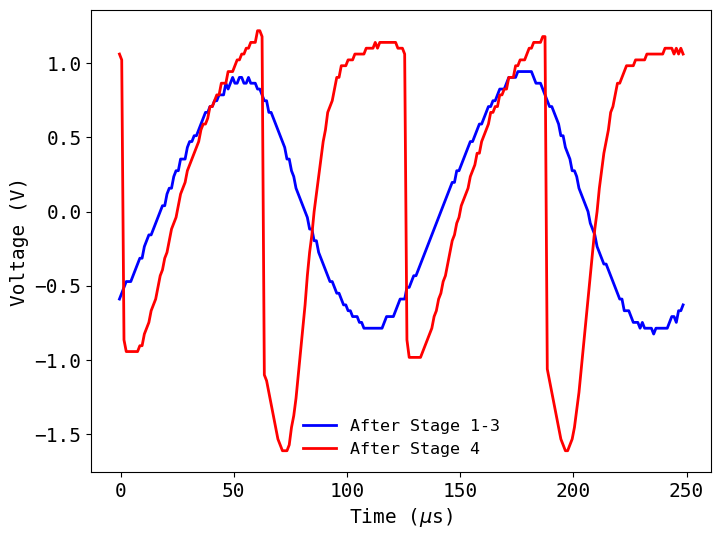

In [109]:
fig, ax = plt.subplots(figsize=(8,6))
ax.plot(time3[:250], cha3[:250], '-', linewidth =2, color='b', label = 'After Stage 1-3')
ax.plot(time4[:250], cha4[:250], '-', linewidth =2, color='r', label = 'After Stage 4')
#ax.plot(time3[:250], chb3[:250], '-', linewidth =2, color='k', alpha = 1, label = f'$V_r$')
ax.set_xlabel(f'Time ($\\mu$s)', fontsize=14)
ax.set_ylabel('Voltage (V)', fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.legend(loc = 'best', fontsize = 12, frameon = False);

### Stage 4->5

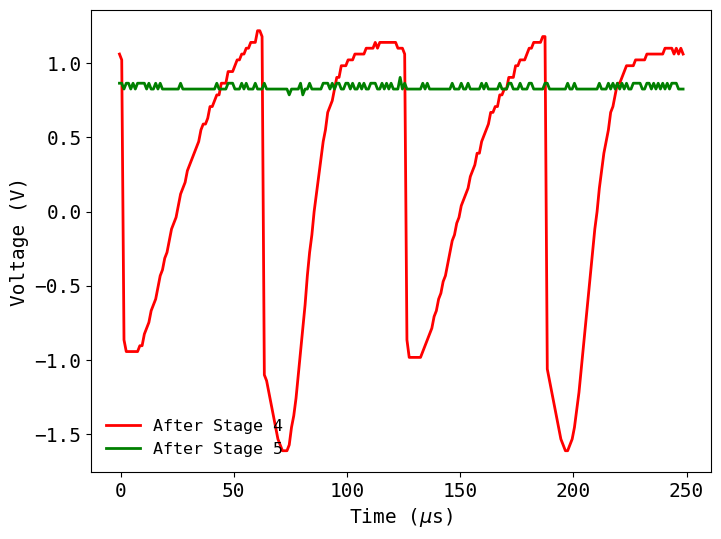

In [110]:
fig, ax = plt.subplots(figsize=(8,6))
ax.plot(time4[:250], cha4[:250], '-', linewidth =2, color='r', label = 'After Stage 4')
ax.plot(time5[:250], cha5[:250], '-', linewidth =2, color='g', label = 'After Stage 5')
#ax.plot(time4[:250], chb4[:250], '-', linewidth =2, color='k', alpha = 1, label = f'$V_r$')
ax.set_xlabel(f'Time ($\\mu$s)', fontsize=14)
ax.set_ylabel('Voltage (V)', fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.legend(loc = 'lower left', fontsize = 12, frameon = False);

### Stage 1->5

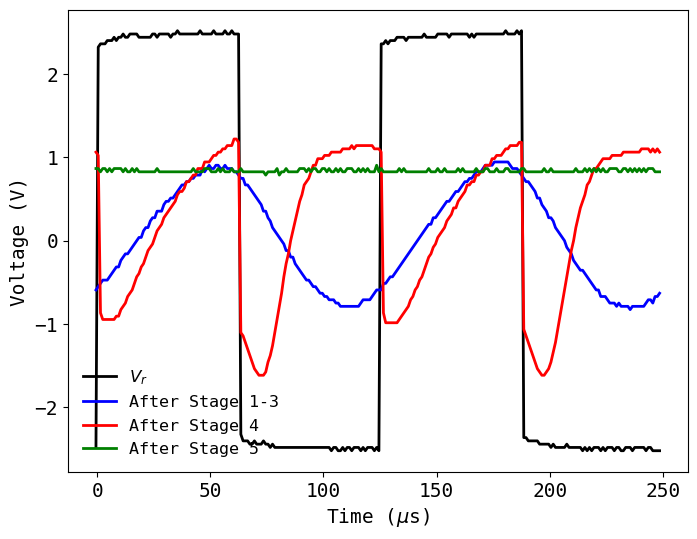

In [111]:
fig, ax = plt.subplots(figsize=(8,6))
ax.plot(time3[:250], chb3[:250], '-', linewidth =2, color='k', label = f'$V_r$')
ax.plot(time3[:250], cha3[:250], '-', linewidth =2, color='b', label = 'After Stage 1-3')
ax.plot(time4[:250], cha4[:250], '-', linewidth =2, color='r', label = 'After Stage 4')
ax.plot(time5[:250], cha5[:250], '-', linewidth =2, color='g', label = 'After Stage 5')
#ax.plot(time4[:250], chb4[:250], '-', linewidth =2, color='k', alpha = 1, label = f'$V_r$')
ax.set_xlabel(f'Time ($\\mu$s)', fontsize=14)
ax.set_ylabel('Voltage (V)', fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.legend(loc = 'lower left', fontsize = 12, frameon = False);

### Double plot

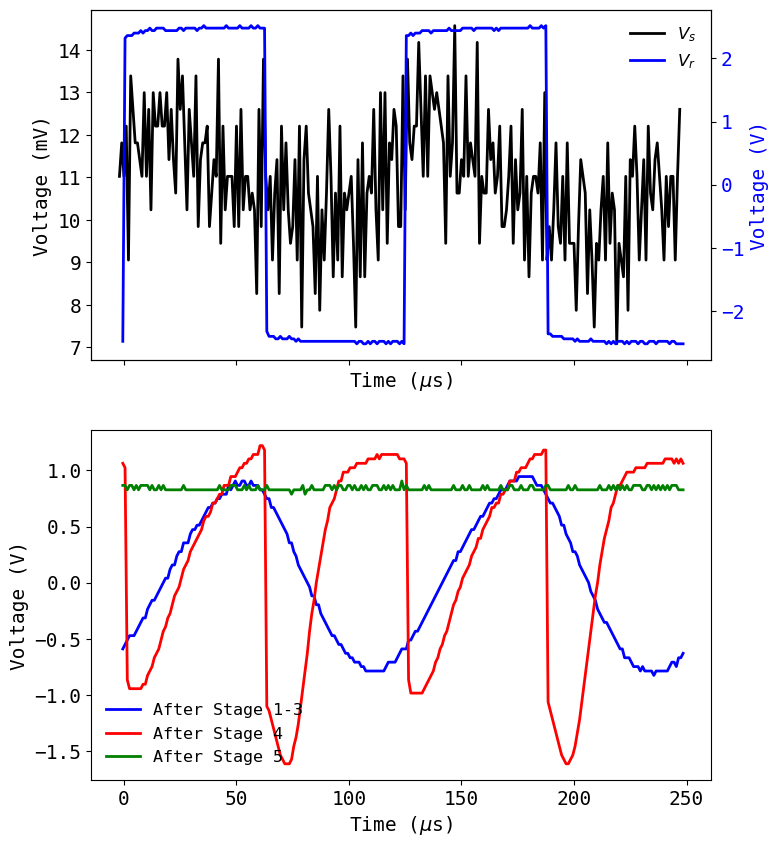

In [112]:
fig, axes = plt.subplots(2, 1, figsize=(8,10), sharex=True)

line_ori = axes[0].plot(time0[:250], cha0[:250], '-', linewidth =2, color='k', label = f'$V_s$')
axes[0].set_xlabel(f'Time ($\\mu$s)', fontsize=14)
axes[0].set_ylabel('Voltage (mV)', fontsize=14, color = 'k')
axes[0].tick_params(axis='y', labelcolor='k')
axes[0].tick_params(axis='both', which='major', labelsize=14)

ax_twin = axes[0].twinx()
line_twin = ax_twin.plot(time3[:250], chb3[:250], '-', linewidth =2, color='b', label = f'$V_r$')
ax_twin.set_ylabel('Voltage (V)', fontsize=14, color = 'b')
ax_twin.tick_params(axis='y', labelcolor='b')
ax_twin.tick_params(axis='both', which='major', labelsize=14)

lines = [line_ori[0], line_twin[0]]
labels = [line.get_label() for line in lines]
axes[0].legend(lines, labels, loc='best', fontsize =12, frameon=False);

axes[1].plot(time3[:250], cha3[:250], '-', linewidth =2, color='b', label = 'After Stage 1-3')
axes[1].plot(time4[:250], cha4[:250], '-', linewidth =2, color='r', label = 'After Stage 4')
axes[1].plot(time5[:250], cha5[:250], '-', linewidth =2, color='g', label = 'After Stage 5')
axes[1].set_xlabel(f'Time ($\\mu$s)', fontsize=14)  
axes[1].set_ylabel('Voltage (V)', fontsize=14)
axes[1].tick_params(axis='both', which='major', labelsize=14)
axes[1].legend(loc = 'lower left', fontsize = 12, frameon = False);


### Final plots

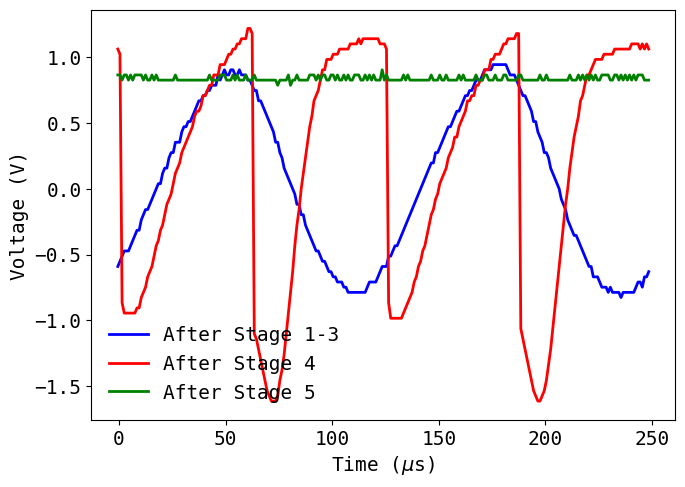

In [113]:
AXES_RECT = [0.15, 0.13, 0.73, 0.82]  # [left, bottom, width, height]


fig = plt.figure(figsize=(8, 5))
ax = fig.add_axes(AXES_RECT)
ax.plot(time3[:250], cha3[:250], '-', linewidth =2, color='b', label = 'After Stage 1-3')
ax.plot(time4[:250], cha4[:250], '-', linewidth =2, color='r', label = 'After Stage 4')
ax.plot(time5[:250], cha5[:250], '-', linewidth =2, color='g', label = 'After Stage 5')
ax.set_xlabel(f'Time ($\\mu$s)', fontsize=14)
ax.set_ylabel('Voltage (V)', fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.legend(loc = 'best', fontsize = 14, frameon = False)
fig.subplots_adjust(left=0.12, right=0.88, bottom=0.12, top=0.95)
plt.savefig('stages_1to5.pdf', dpi=600);

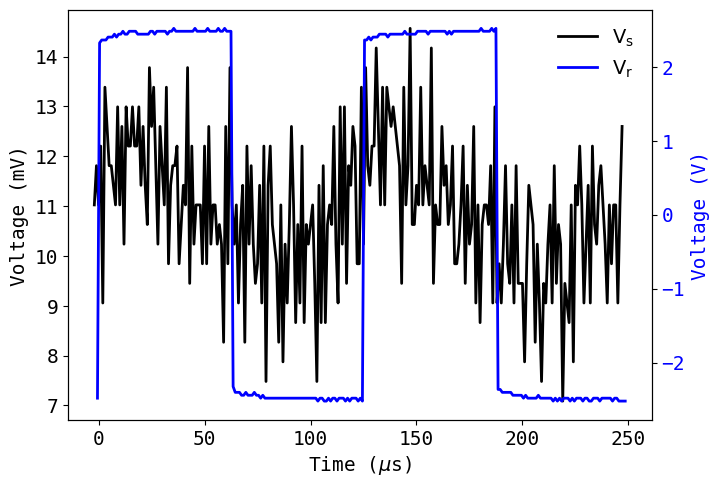

In [114]:
fig = plt.figure(figsize=(8, 5))
ax = fig.add_axes(AXES_RECT)
line_ori = ax.plot(time0[:250], cha0[:250], '-', linewidth =2, color='k', label = r'$\mathrm{V_s}$')
ax.set_xlabel(f'Time ($\\mu$s)', fontsize=14)
ax.set_ylabel('Voltage (mV)', fontsize=14, color = 'k')
ax.tick_params(axis='y', labelcolor='k')
ax.tick_params(axis='both', which='major', labelsize=14)

ax_twin = ax.twinx()
line_twin = ax_twin.plot(time3[:250], chb3[:250], '-', linewidth =2, color='b', label = r'$\mathrm{V_r}$')
ax_twin.set_ylabel('Voltage (V)', fontsize=14, color = 'b')
ax_twin.tick_params(axis='y', labelcolor='b')
ax_twin.tick_params(axis='both', which='major', labelsize=14)

lines = [line_ori[0], line_twin[0]]
labels = [line.get_label() for line in lines]
ax.legend(lines, labels, loc='best', fontsize =14, frameon=False)
fig.subplots_adjust(left=0.12, right=0.88, bottom=0.12, top=0.95)
plt.savefig('stage0plusref.pdf', dpi=600);
